**Importations, Configurations et Chargement**

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kruskal, chi2_contingency
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# ── Configuration esthétique et répertoires ──
sns.set_theme(style="whitegrid")
PALETTE = {'CN': '#2ECC71', 'MCI': '#F39C12', 'AD': '#E74C3C'}
os.makedirs("../reports/figures", exist_ok=True)

# Charger le dataset depuis la racine relative du notebook
df = pd.read_csv("../data/raw/alzheimer_clinical.csv")
df['Label_Enc'] = df['Label'].map({'CN': 0, 'MCI': 1, 'AD': 2})

print(f"✅ Données chargées avec succès : {df.shape[0]} patients analysés.")
print(df.groupby('Label').size())

✅ Données chargées avec succès : 1500 patients analysés.
Label
AD     300
CN     675
MCI    525
dtype: int64


**Distribution des Classes et Analyse du Déséquilibre**

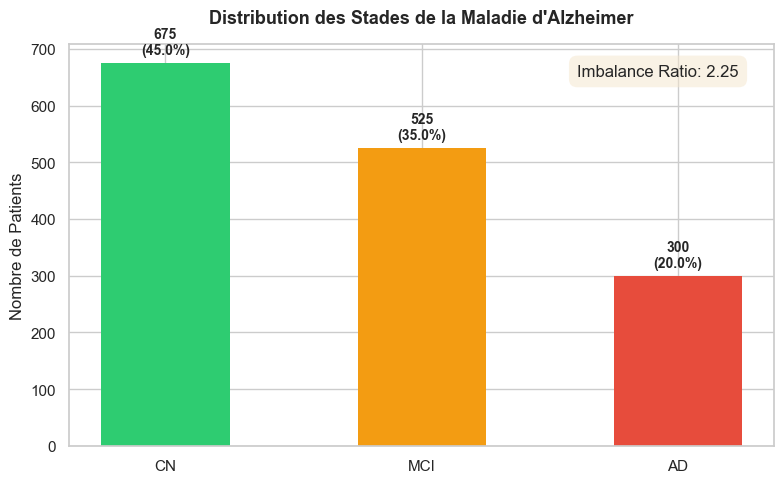

In [2]:
# ── 1. Distribution des classes ──
fig, ax = plt.subplots(figsize=(8, 5))

counts = df['Label'].value_counts()
bars = ax.bar(counts.index, counts.values, color=[PALETTE[l] for l in counts.index], edgecolor='none', width=0.5)
ax.set_title("Distribution des Stades de la Maladie d'Alzheimer", fontsize=13, fontweight='bold', pad=15)
ax.set_ylabel("Nombre de Patients")

# Ajouter les pourcentages au-dessus des barres
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 10,
            f'{int(height)}\n({height/len(df)*100:.1f}%)',
            ha='center', va='bottom', fontweight='bold', fontsize=10)

# Calcul et affichage de l'Imbalance Ratio
ir = counts.max() / counts.min()
ax.text(0.95, 0.95, f'Imbalance Ratio: {ir:.2f}',
        transform=ax.transAxes, ha='right', va='top',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#F5E6CC', alpha=0.5, edgecolor='none'))

plt.tight_layout()
plt.savefig("../reports/figures/01_class_distribution.png", dpi=200, bbox_inches='tight')
plt.show()

**Tests Statistiques Non-Paramétriques (Kruskal-Wallis)**

In [4]:
# ── 2. Tests de Kruskal-Wallis (Rigueur Statistique) ──
numerical_features = ['Age', 'MMSE', 'nWBV', 'eTIV', 'ASF', 'Abeta42', 'pTau181', 'NfL', 'FAQ', 'Education']

kw_results = []
for feat in numerical_features:
    # On isole les groupes en retirant les NaN pour le test statistique
    groups = [df.loc[df['Label'] == l, feat].dropna().values for l in ['CN', 'MCI', 'AD']]
    stat, pval = kruskal(*groups)
    kw_results.append({
        'Feature': feat,
        'H_statistic': round(stat, 2),
        'p_value': pval,
        'Significant (p < 0.05)': '✅' if pval < 0.05 else '❌'
    })

kw_df = pd.DataFrame(kw_results).sort_values('H_statistic', ascending=False)
print("RÉSULTATS DU TEST DE KRUSKAL-WALLIS :")
print(kw_df.to_string(index=False))

RÉSULTATS DU TEST DE KRUSKAL-WALLIS :
  Feature  H_statistic       p_value Significant (p < 0.05)
     nWBV      1252.82 8.965212e-273                      ✅
      FAQ       978.36 3.563992e-213                      ✅
     MMSE       959.88 3.676226e-209                      ✅
  Abeta42       902.29 1.174730e-196                      ✅
      NfL       835.35 4.044021e-182                      ✅
  pTau181       826.05 4.224891e-180                      ✅
      Age       349.84  1.081945e-76                      ✅
Education       336.66  7.853493e-74                      ✅
      ASF         0.96  6.172929e-01                      ❌
     eTIV         0.70  7.044052e-01                      ❌


**Les Violin Plots (Distribution des Biomarqueurs)**

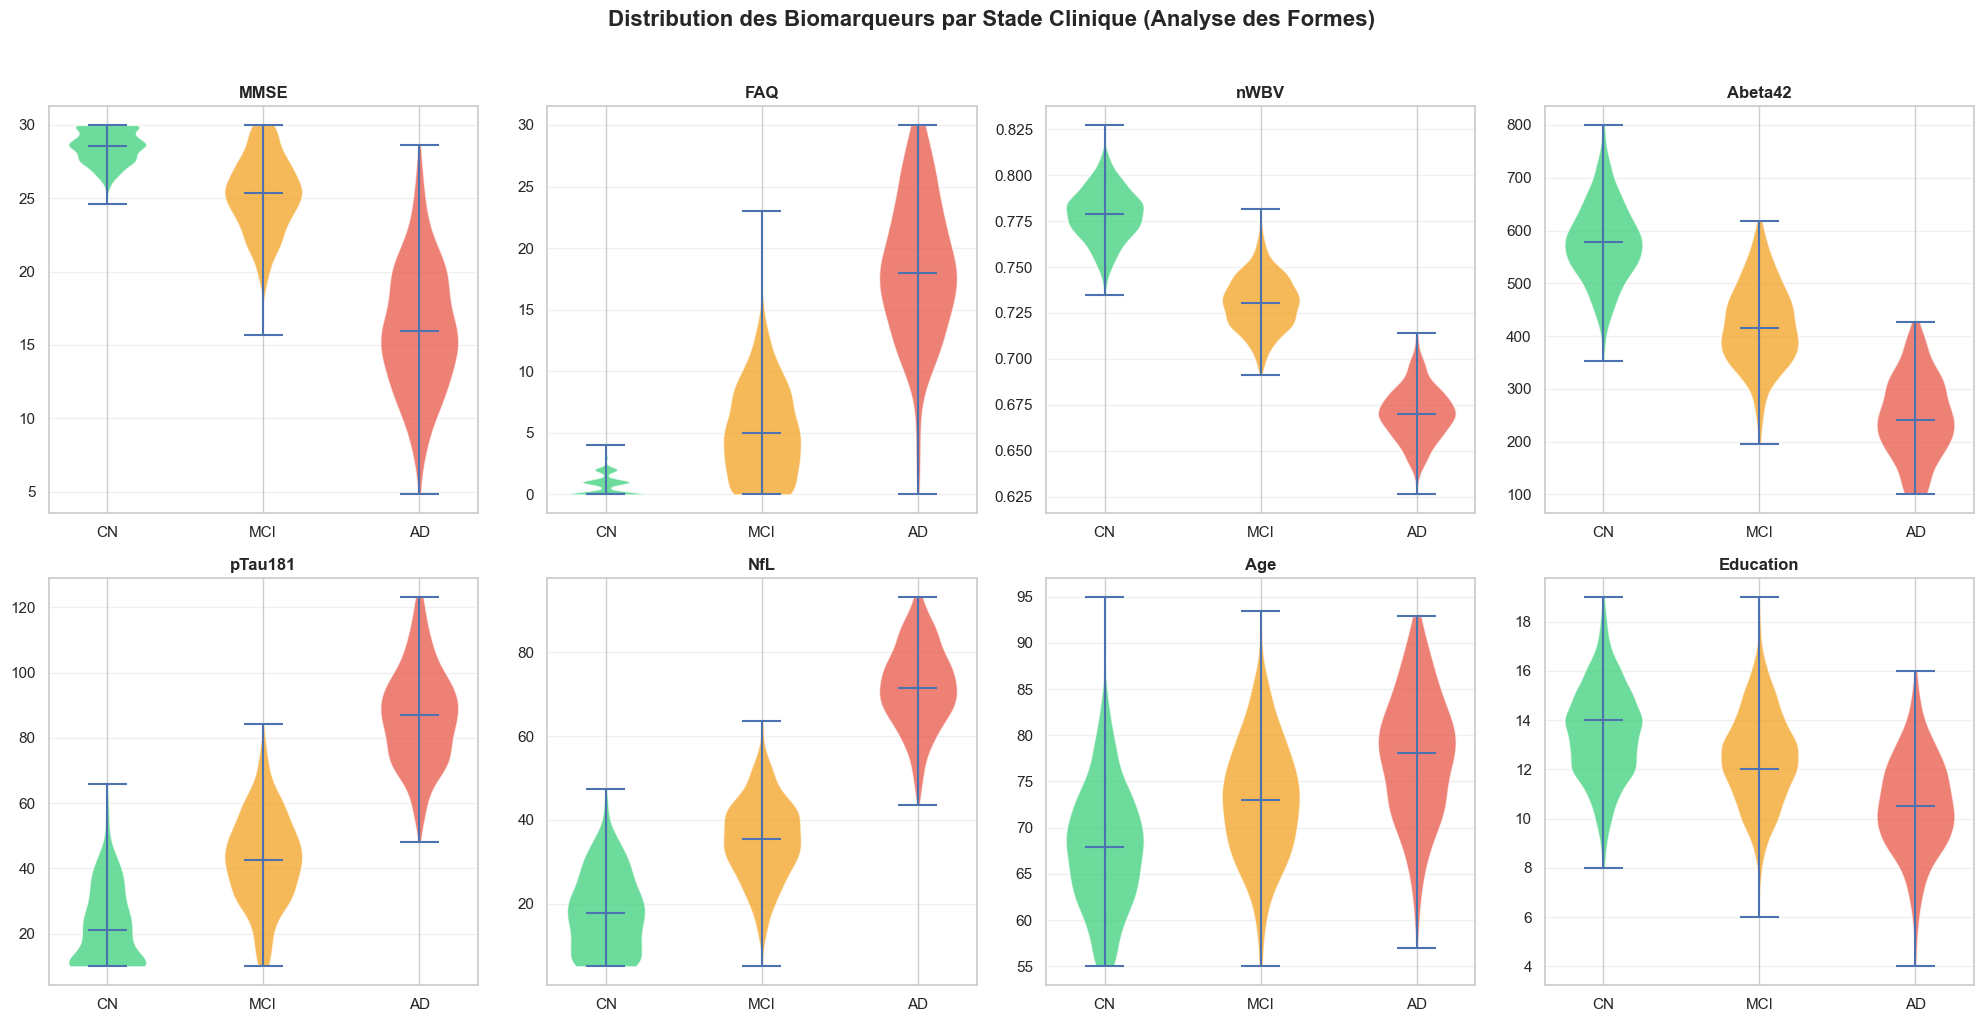

In [ ]:
# ── 3. Violin plots comparatifs
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

key_features = ['MMSE', 'FAQ', 'nWBV', 'Abeta42', 'pTau181', 'NfL', 'Age', 'Education']

for ax, feat in zip(axes, key_features):
    data_by_group = [df.loc[df['Label'] == l, feat].dropna().values for l in ['CN', 'MCI', 'AD']]
    vp = ax.violinplot(data_by_group, positions=[0, 1, 2], showmedians=True, showextrema=True)
    
    for body, color in zip(vp['bodies'], PALETTE.values()):
        body.set_facecolor(color)
        body.set_alpha(0.7)
    
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(['CN', 'MCI', 'AD'])
    ax.set_title(feat, fontweight='bold', fontsize=12)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle("Distribution des Biomarqueurs par Stade Clinique (Analyse des Formes)", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("../reports/figures/02_violin_biomarkers.png", dpi=150, bbox_inches='tight')
plt.show()

**Matrice de Corrélation de Spearman**

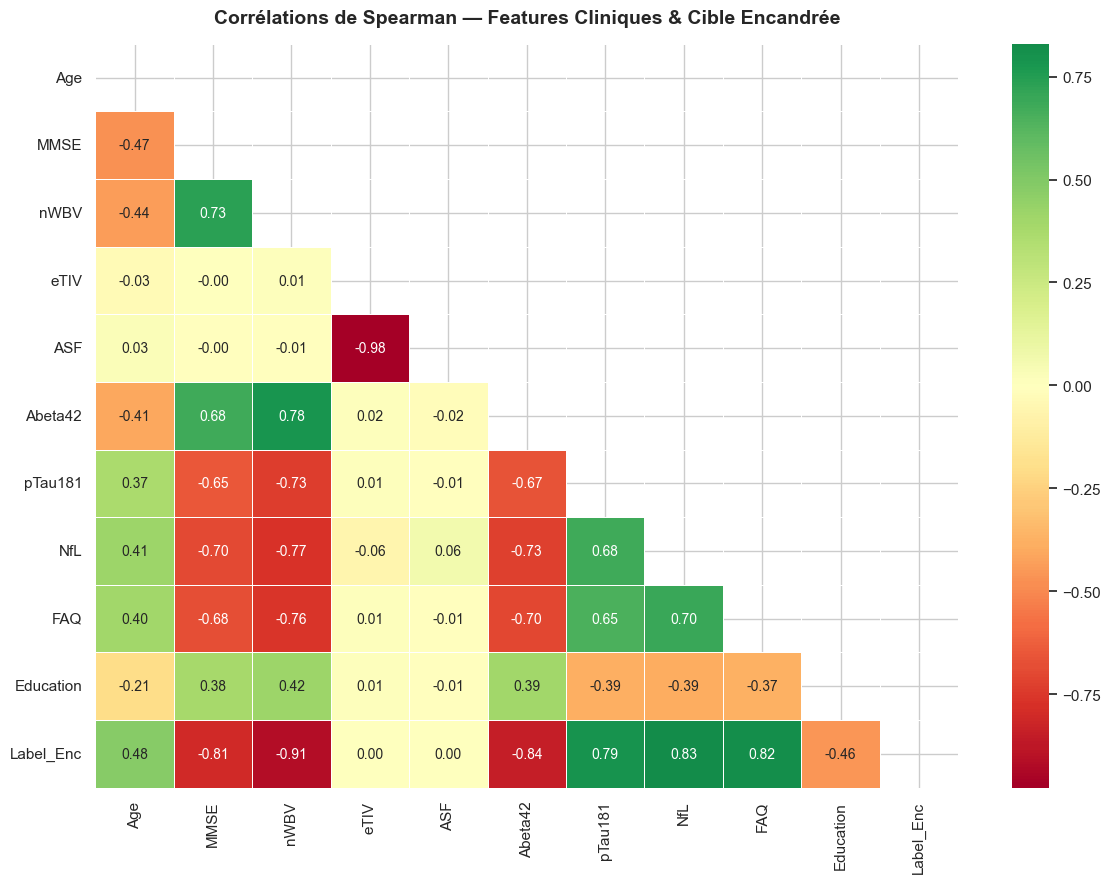

In [ ]:
# ── 4. Correlation matrix 
corr_matrix = df[numerical_features + ['Label_Enc']].corr(method='spearman')

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, ax=ax,
            linewidths=0.5, annot_kws={"size": 10})

ax.set_title("Corrélations de Spearman — Features Cliniques & Cible Encandrée", fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig("../reports/figures/03_correlation_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()

In [7]:
# ── CELLULE DE TEST DU PIPELINE DE PRODUCTION ──
import sys
os.chdir("..") 
from src.preprocessing import create_clinical_features

print("Application du Feature Engineering Clinique depuis le dossier src...")
# Appel de la fonction définie dans src/preprocessing.py
df_engineered = create_clinical_features(df)

# Vérification 
features_creees = ['Amyloid_Tau_Ratio', 'Cog_Functional_Score', 'Brain_Age_Ratio', 'APOE4_Risk']
print("\n Variables cliniques avancées générées avec succès :")
print(df_engineered[features_creees].head())

Application du Feature Engineering Clinique depuis le dossier src...

 Variables cliniques avancées générées avec succès :
   Amyloid_Tau_Ratio  Cog_Functional_Score  Brain_Age_Ratio  APOE4_Risk
0                NaN              0.730985         0.936194         3.0
1           4.399836             -0.277101         0.856582        15.0
2                NaN              0.974203         1.154918         1.0
3                NaN              0.897261         0.966426         1.0
4          15.446888              0.940757         1.071598         1.0
